## Test case

In [12]:
from autocallable_note import AutocallableNote
from time import perf_counter

r = 0.0375
q = 0.01
sigma = 0.25
S_0 = 100.0
N = 100.0
trading_days = 252
n_traj = 1_000_000
autocall_ratio = 1.00
knock_in_ratio = 0.70
c = 0.1

start = perf_counter()

system = AutocallableNote(
    r = r, 
    q = q, 
    sigma = sigma, 
    S_0 = S_0, 
    N = N, 
    trading_days = trading_days, 
    n_traj = 1000000,
    autocall_ratio = autocall_ratio,
    knock_in_ratio = knock_in_ratio,
    c = c)


system.gbm_simulator()
system.summary()


run_time = perf_counter() - start
print('ran ',n_traj,' stochastic trajectories')
print('run_time:',run_time,' s')

100%|██████████| 252/252 [00:04<00:00, 61.62it/s]


AUTOCALLABLE NOTE MONTE CARLO RESULTS

DISCOUNTED PAYOFF (PRESENT VALUE)
------------------------------------------------------------
Expected discounted payoff: 98.5749
Standard deviation:         12.3309
Minimum:                    30.3103
Maximum:                    105.9514
Monte Carlo standard error: 0.0123
95% confidence interval:    [98.5508, 98.5991]

UNDISCOUNTED PAYOFF
------------------------------------------------------------
Expected payoff:             100.5772
Standard deviation:          12.3915
Minimum:                     31.4685
Maximum:                     110.0000
Monte Carlo standard error:  0.0124
95% confidence interval:     [100.5529, 100.6015]

PATH STATISTICS
------------------------------------------------------------
Knock-in probability:        12.33%
Early-autocall probability:  68.39%
Maturity-payment probability:  31.61%
ran  1000000  stochastic trajectories
run_time: 4.122900125000342  s


### Try real data

If we construct a autocallablenote using the underlying asset of AAPL

In [14]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ticker_symbol = "AAPL"

ticker = yf.Ticker(ticker_symbol)
history = ticker.history(period="2y",auto_adjust=True)


S_0 = float(history["Close"].iloc[-1])

# Annualised historical volatility.
log_returns = np.log(history["Close"]).diff().dropna()
sigma = float(log_returns.std(ddof=1) * np.sqrt(252))

# Trailing one-year dividend yield.
annual_dividends = float(ticker.get_dividends(period="1y").sum())

q_simple = annual_dividends / S_0
q = float(np.log1p(q_simple))

# Latest one-year US Treasury yield from FRED.
rates = pd.read_csv("https://fred.stlouisfed.org/graph/""fredgraph.csv?id=DGS1")
latest_rate = pd.to_numeric(rates["DGS1"],errors="coerce",).dropna().iloc[-1]

r_simple = float(latest_rate) / 100.0
r = float(np.log1p(r_simple))

N = 100.

start = perf_counter()

instrument = AutocallableNote(
    r = r, 
    q = q, 
    sigma = sigma, 
    S_0 = S_0, 
    N = N, 
    trading_days = trading_days, 
    n_traj = 1000000,
    autocall_ratio = autocall_ratio,
    knock_in_ratio = knock_in_ratio,
    c = c)

print(
    f"Model and product inputs:\n"
    f"  Initial stock price (S_0): {S_0:.2f}\n"
    f"  Risk-free rate (r):        {r:.2%}\n"
    f"  Dividend yield (q):        {q:.2%}\n"
    f"  Annualised volatility:     {sigma:.2%}\n"
    f"  Annual coupon rate (c):    {c:.2%}\n"
    f"  Autocall ratio:            {autocall_ratio:.2%}\n"
    f"  Knock-in ratio:            {knock_in_ratio:.2%}"
)


instrument.gbm_simulator()
print('****************** running the simulation ******************')
instrument.summary()

run_time = perf_counter() - start
print('ran ',n_traj,' stochastic trajectories')
print('run_time:',run_time,' s')

Model and product inputs:
  Initial stock price (S_0): 340.30
  Risk-free rate (r):        4.34%
  Dividend yield (q):        0.31%
  Annualised volatility:     28.69%
  Annual coupon rate (c):    10.00%
  Autocall ratio:            100.00%
  Knock-in ratio:            70.00%


100%|██████████| 252/252 [00:04<00:00, 61.85it/s]

****************** running the simulation ******************

AUTOCALLABLE NOTE MONTE CARLO RESULTS

DISCOUNTED PAYOFF (PRESENT VALUE)
------------------------------------------------------------
Expected discounted payoff: 96.7544
Standard deviation:         14.0402
Minimum:                    22.3585
Maximum:                    105.3236
Monte Carlo standard error: 0.0140
95% confidence interval:    [96.7268, 96.7819]

UNDISCOUNTED PAYOFF
------------------------------------------------------------
Expected payoff:             98.9917
Standard deviation:          14.0045
Minimum:                     23.3512
Maximum:                     110.0000
Monte Carlo standard error:  0.0140
95% confidence interval:     [98.9642, 99.0191]

PATH STATISTICS
------------------------------------------------------------
Knock-in probability:        16.41%
Early-autocall probability:  68.74%
Maturity-payment probability:  31.26%
ran  1000000  stochastic trajectories
run_time: 4.102708291999988  s


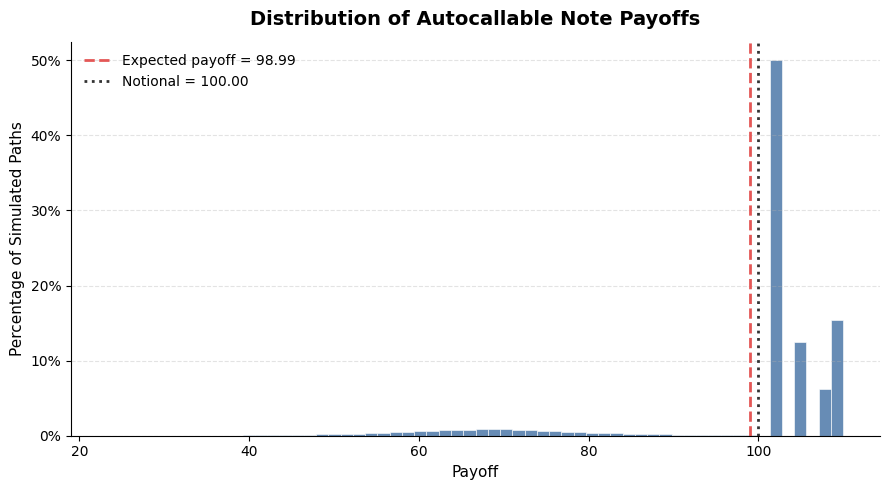

In [15]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np


payoff = instrument.payoff
weights = np.ones_like(payoff) / payoff.size

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    payoff,
    bins=60,
    weights=weights,
    color="#4C78A8",
    alpha=0.85,
    edgecolor="white",
    linewidth=0.5,
)

# Mark the expected payoff.
ax.axvline(
    payoff.mean(),
    color="#E45756",
    linestyle="--",
    linewidth=2,
    label=f"Expected payoff = {payoff.mean():.2f}",
)

# Mark the original notional.
ax.axvline(
    instrument.N,
    color="#333333",
    linestyle=":",
    linewidth=2,
    label=f"Notional = {instrument.N:.2f}",
)

ax.set_title(
    "Distribution of Autocallable Note Payoffs",
    fontsize=14,
    fontweight="bold",
    pad=12,
)

ax.set_xlabel("Payoff", fontsize=11)
ax.set_ylabel("Percentage of Simulated Paths", fontsize=11)

ax.yaxis.set_major_formatter(
    PercentFormatter(xmax=1.0)
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False)

fig.tight_layout()
plt.show()

## Do some convergence test

100%|██████████| 252/252 [00:01<00:00, 217.48it/s]


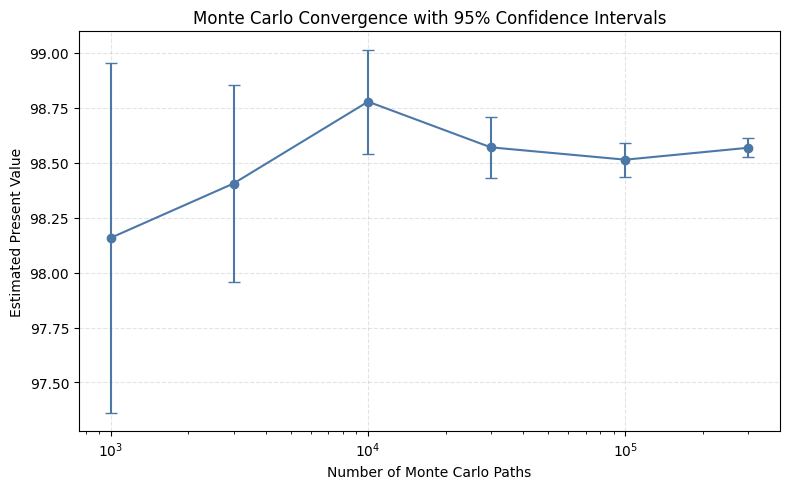

In [16]:
import numpy as np
import matplotlib.pyplot as plt

path_counts = [
    1_000,
    3_000,
    10_000,
    30_000,
    100_000,
    300_000,
]

estimated_values = []
standard_errors = []

for n_paths in path_counts:
    note = AutocallableNote(
        n_traj=n_paths,
    )

    note.gbm_simulator()

    estimated_values.append(
        note.estimated_value
    )

    standard_errors.append(
        note.standard_error
    )

estimated_values = np.array(estimated_values)
standard_errors = np.array(standard_errors)

plt.figure(figsize=(8, 5))

plt.errorbar(
    path_counts,
    estimated_values,
    yerr=1.96 * standard_errors,
    fmt="o-",
    capsize=4,
    color="#4C78A8",
)

plt.xscale("log")

plt.xlabel("Number of Monte Carlo Paths")
plt.ylabel("Estimated Present Value")
plt.title("Monte Carlo Convergence with 95% Confidence Intervals")

plt.grid(
    linestyle="--",
    alpha=0.35,
)

plt.tight_layout()
plt.show()